# Plan and solve agent

We'll begin with the planner functionality, and define the data structure and the corresponding instructions:

In [2]:
# Cell for loading environment variables from config.py,
# which is located one directory above this notebook.
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, parent_dir)

from config import set_environment

set_environment()

In [27]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

class Plan(BaseModel):
    """Plan to follow in future"""
    steps: list[str] = Field(description="different steps to follow, should be in sorted order")

system_prompt_template = (
    "For the given task, come up with a step by step plan.\n"
    "This plan should involve individual tasks, that if executed correctly will "
    "yield the correct answer. Do not add any superfluous steps.\n"
    "The result of the final step should be the final answer. Make sure that each "
    "step has all the information needed - do no skip steps."
)

# planner_prompt = ChatPromptTemplate.from_messages(
#     [
#         SystemMessage(content=system_prompt_template),
#         HumanMessage(content="Prepare a plan how to solve the following task: {task}"),
#     ]
# )


planner_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt_template),
        ("user", "Prepare a plan how to solve the following task:\n{task}\n"),
    ]
)

planner = planner_prompt | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0).with_structured_output(Plan)

We will re-use tools we built in previous sections:

In [28]:
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableLambda, RunnableConfig
from langchain_core.tools import tool, convert_runnable_to_tool
import numexpr as ne

class CalculatorArgs(BaseModel):
    expression: str = Field(description="Mathematical expression to be evaluated")

def calculator(state: CalculatorArgs, config: RunnableConfig) -> str:
    expression = state["expression"]
    math_constants = config["configurable"].get("math_constants", {})
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)

calculator_with_retry = RunnableLambda(calculator).with_retry(
    wait_exponential_jitter=True,
    stop_after_attempt=3,
)

calculator_tool = convert_runnable_to_tool(
    calculator_with_retry,
    name="calculator",
    description=(
        "Calculates a single mathematical expression, incl. complex numbers."
        "'\nAlways add * operations, examples:\n73i -> 73*i\n"
        "7pi**2 -> 7*pi**2"
    ),
    args_schema=CalculatorArgs,
    arg_types={"expression": "str"},
)

In [29]:
from langchain_community.agent_toolkits.load_tools import load_tools

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
tools = load_tools(
    tool_names=["ddg-search", "arxiv", "wikipedia"],
    llm=llm
)

We will use these tools with a ReACT agent:

In [30]:
from langgraph.prebuilt import create_react_agent
from langgraph.prebuilt.chat_agent_executor import AgentState

system_prompt = (
    "You're a smart assistant that carefully helps to solve complex tasks.\n"
    " Given a general plan to solve a task and a specific step, work on this step. "
    " Don't assume anything, keep in minds things might change and always try to "
    "use tools to double-check yourself.\m"
    " Use a calculator for mathematical computations, use Search to gather"
    "for information about common facts, fresh events and news, use Arxiv to get "
    "ideas on recent research and use Wikipedia for common knowledge."
)

step_template = (
    "Given the task and the plan, try to execute on a specific step of the plan.\n"
    "TASK:\n{task}\n\nPLAN:\n{plan}\n\nSTEP TO EXECUTE:\n{step}\n"
)

# prompt_template = ChatPromptTemplate.from_messages([
#     SystemMessage(content=system_prompt),
#     HumanMessage(content=step_template),
# ])

prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("user", step_template),
    ]
)

class StepState(AgentState):
    plan: str
    step: str
    task: str

execution_agent = create_react_agent(
    model=llm,
    tools=tools+[calculator_tool],
    state_schema=StepState,
    prompt=prompt_template,
)

Now it's time to define our agent's state:

In [31]:
from typing import Annotated, TypedDict
import operator

task = "Write a strategic one-pagr of building an AI startup"

In [32]:
class PlanState(TypedDict):
    task: str
    plan: Plan
    past_steps: Annotated[list[str], operator.add]
    final_response: str


def get_current_step(state: PlanState) -> int:
    """Returns the number of current step to be executed."""
    return len(state.get("past_steps", []))


def get_full_plan(state: PlanState) -> str:
    """Returns formatted plan with step numbers and past results."""
    full_plan = []
    for i, step in enumerate(state["plan"].steps):
        full_step = f"# {i+1}. Planned step: {step}\n"
        if i < get_current_step(state):
            full_step += f"Result: {state['past_steps'][i]}\n"
        full_plan.append(full_step)
    return "\n".join(full_plan)

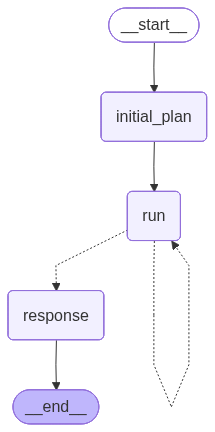

In [33]:
from typing import Literal
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END


final_prompt = PromptTemplate.from_template(
    "You're a helpful assistant that has executed on a plan."
    "Given the results of the execution, prepare the final response.\n"
    "Don't assume anything\nTASK:\n{task}\n\nPLAN WITH RESUlTS:\n{plan}\n"
    "FINAL RESPONSE:\n"
)


async def _build_initial_plan(state: PlanState) -> PlanState:
    plan = await planner.ainvoke(state["task"])
    return {"plan": plan}


async def _run_step(state: PlanState) -> PlanState:
    plan = state["plan"]
    current_step = get_current_step(state)
    step = await execution_agent.ainvoke(
        {
            "plan": get_full_plan(state),
            "step": plan.steps[current_step],
            "task": state["task"],
        }
    )
    return {"past_steps": [step["messages"][-1].content]}


async def _get_final_response(state: PlanState) -> PlanState:
    final_response = await (final_prompt | llm).ainvoke(
        {"task": state["task"], "plan": get_full_plan(state)}
    )
    return {"final_response": final_response}


def _should_continue(state: PlanState) -> Literal["run", "response"]:
    if get_current_step(state) < len(state["plan"].steps):
        return "run"
    return "response"


builder = StateGraph(PlanState)
builder.add_node("initial_plan", _build_initial_plan)
builder.add_node("run", _run_step)
builder.add_node("response", _get_final_response)

builder.add_edge(START, "initial_plan")
builder.add_edge("initial_plan", "run")
builder.add_conditional_edges("run", _should_continue)
builder.add_edge("response", END)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

Now it's time to run it!

In [36]:
task = "Write a strategic one-pager of building an AI startup keep the steps to 10 or below"
result = await graph.ainvoke({"task": task})

In [37]:
print(result["final_response"].content)

## GrowthPilot AI: Unlocking E-commerce Growth Through Intelligent Data Mastery

**Tagline:** Transform Data into Decisions. Drive Growth.

---

### **The Problem**

E-commerce Small and Medium-sized Enterprises (SMEs) are drowning in data, yet starved for actionable insights. The overwhelming and unstructured nature of data actively impedes effective decision-making, resulting in:

*   **Significant Revenue Loss:** Stemming from inefficient inventory, generic customer experiences, and suboptimal marketing spend.
*   **Crippling Operational Inefficiencies:** Due to fragmented analytics and a lack of real-time demand sensing.
*   **Erosion of Competitive Edge:** As SMEs struggle to compete with larger, data-savvy enterprises.

---

### **The Solution: GrowthPilot AI**

GrowthPilot AI is an intelligent SaaS platform that empowers e-commerce SMEs by transforming raw, disparate data into actionable insights and automated optimizations. It acts as a virtual data scientist and operations man

We can also explore detailed steps:

In [39]:
async for output in graph.astream({"task": task}, stream_mode="updates"):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'initial_plan':
---
{'plan': Plan(steps=['Clearly define the core problem or market opportunity the AI startup will address.', 'Articulate the unique AI-driven solution or technology that solves the defined problem.', 'Identify the target market, customer segments, and the specific value proposition for them.', 'Outline the proposed business model, including revenue streams, pricing strategy, and go-to-market plan.', "Summarize the competitive landscape and highlight the startup's key differentiators and competitive advantage.", "Describe the founding team's core expertise and why they are uniquely positioned to execute.", 'Establish the initial product roadmap, key milestones, and short-term strategic goals.', 'Determine the essential funding needs and a high-level strategy for securing investment (if applicable).', "Identify the critical success metrics (KPIs) that will measure the startup's progress and impact.", 'Draft the strategic one-pager, ensuring all key elem